# 순환 신경망 기반 감성 분석 (네이버 영화 리뷰)
1. 데이터 준비
2. 모델 구축 및 컴파일
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리 
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터준비 

### 1-1. 데이터 로딩

In [1]:
# naver_movie_review.csv
import pandas as pd
df = pd.read_csv('data/naver_movie_review.csv')
df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [2]:
# 결측치 확인
df[df.document.isnull()] # boolean 인덱싱

,id,document,label
25857,2172111,NaN,1
55737,6369843,NaN,1
110014,1034280,NaN,0
126782,5942978,NaN,0
140721,1034283,NaN,0
155746,402110,NaN,1
157899,5026896,NaN,0
177097,511097,NaN,1


In [3]:
# 결측치 제거
df.dropna(subset='document', inplace=True)
df.info(), df.isnull()

<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        199992 non-null  int64 
 1   document  199992 non-null  object
 2   label     199992 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 6.1+ MB


(None,
            id  document  label
 0       False     False  False
 1       False     False  False
 2       False     False  False
 3       False     False  False
 4       False     False  False
 ...       ...       ...    ...
 199995  False     False  False
 199996  False     False  False
 199997  False     False  False
 199998  False     False  False
 199999  False     False  False
 
 [199992 rows x 3 columns])

#### 1-2-2. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 문장은 공백만 남아있게 되므로, 결측치 삭제 처리 진행 필요

In [4]:
# 한글과 공백 제외하고 모두 공백으로 치환
df['clean_doc'] = df.document.replace(r'[^ㄱ-ㅎㅏ-ㅣ가-힣]+', ' ', regex=True).str.strip() # 이게 시작,끝공백 제거
print(df.clean_doc)
# 문장의 시작 부분에 있는 공백을 ""으로 치환 
# df.clean_doc.replace(r'^\s+', '', regex=True, inplace=True)
# 빈 문자열("")은 결측치로 수정
df.clean_doc = df.clean_doc.replace('', None)
df.info()

0                                         아 더빙 진짜 짜증나네요 목소리
1                              흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나
2                                         너무재밓었다그래서보는것을추천한다
3                                교도소 이야기구먼 솔직히 재미는 없다 평점 조정
4         사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...
                                ...                        
199995            오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함
199996              의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따
199997                      그림도 좋고 완성도도 높았지만 보는 내내 불안하게 만든다
199998           절대 봐서는 안 될 영화 재미도 없고 기분만 잡치고 한 세트장에서 다 해먹네
199999                                           마무리는 또 왜이래
Name: clean_doc, Length: 199992, dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         199992 non-null  int64 
 1   document   199992 non-null  object
 2   label      199992 non-n

In [5]:
# 결측치 확인
df[df.clean_doc.isnull()]

,id,document,label,clean_doc
404,4221289,What is this movie for?,0,None
412,9509970,Yesterday when i was young,1,None
470,10147571,once upon a dream,1,None
584,7117896,1,0,None
593,6478189,4,0,None
...,...,...,...,...
199459,6381245,take me for what i am,1,None
199563,2192893,good!,0,None
199803,5309713,good~!,1,None
199871,9767991,dkajlskgjqlkrjgklqejgkle,0,None


In [6]:
# 결측치 제거
df.dropna(subset='clean_doc', inplace=True)
df.clean_doc.isnull().sum()

0

#### 1-2-3. 중복치 제거

In [7]:
# 중복치 확인
df[df.clean_doc.duplicated()]

,id,document,label,clean_doc
1097,2062443,쵝오,1,쵝오
1165,7508856,최고!!,1,최고
1248,3502685,최고,1,최고
1483,775332,최고,1,최고
1531,2196647,재밌군..,1,재밌군
...,...,...,...,...
199847,5766993,진리.,1,진리
199861,9301787,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비. 역시 짐 캐리 최고의 영화는 트...,0,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비 역시 짐 캐리 최고의 영화는 트루먼 쇼
199923,4540652,재미있게 봤습니다!,1,재미있게 봤습니다
199934,6929887,굿,1,굿


In [8]:
# 중복치 제거
df.drop_duplicates(subset='clean_doc', keep='first', inplace=True)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190736 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         190736 non-null  int64 
 1   document   190736 non-null  object
 2   label      190736 non-null  int64 
 3   clean_doc  190736 non-null  object
dtypes: int64(2), object(2)
memory usage: 7.3+ MB


#### 1-2-4. 토큰화

In [10]:
# 형태소 분석기 적용 (Okt, Komoran 등)
from konlpy.tag import Okt

from tqdm import tqdm
tqdm.pandas()  # 진행상황 표시해주는 친구
okt = Okt()

# 1. 한국어 텍스트 분석에 흔히 쓰이는 불용어 리스트 정의
# 프로젝트 성격에 맞춰 필요한 단어를 자유롭게 추가/제거 하세요!
stopwords = set([
    '의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', '를', '으로', 
    '자', '에', '와', '한', '하다', '네', '음', '앗', '어', '것', '수', '그', '때', '다'
])

# 2. 토큰화(어간 추출)와 불용어 제거를 한 번에 처리하는 함수 정의
def tokenize_and_remove_stopwords(text):
    # 혹시 모를 결측치(NaN/None) 에러 방지용 안전장치
    if not isinstance(text, str):
        return []
    
    # 1단계: 형태소 분석 및 어간 추출 (예: '재밌네요' -> '재밌다')
    tokens = okt.morphs(text, stem=True)
    
    # 2단계: 뽑아낸 토큰 중 불용어 리스트에 없는 단어만 남기기
    clean_tokens = [word for word in tokens if word not in stopwords]
    
    return clean_tokens

# 3. 데이터프레임에 함수 적용
df['tokens'] = df.clean_doc.progress_apply(tokenize_and_remove_stopwords)

# 결과 확인
print(df['tokens'].head())

100%|██████████| 190736/190736 [03:28<00:00, 916.55it/s] 

0                               [아, 더빙, 진짜, 짜증나다, 목소리]
1         [흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍다, 않다]
2                          [너, 무재, 밓었, 다그, 래서, 보다, 추천]
3                 [교도소, 이야기, 구먼, 솔직하다, 재미, 없다, 평점, 조정]
4    [사이, 몬페, 익살스럽다, 연기, 돋보이다, 영화, 스파이더맨, 에서, 늙다, 보...
Name: tokens, dtype: object


In [11]:
df.head()

,id,document,label,clean_doc,tokens
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리,"[아, 더빙, 진짜, 짜증나다, 목소리]"
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,"[흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍다, 않다]"
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,"[너, 무재, 밓었, 다그, 래서, 보다, 추천]"
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,"[교도소, 이야기, 구먼, 솔직하다, 재미, 없다, 평점, 조정]"
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,"[사이, 몬페, 익살스럽다, 연기, 돋보이다, 영화, 스파이더맨, 에서, 늙다, 보..."


### 1-3. 데이터 분리
* 정답 데이터의 분포 확인 -> 학습용 데이터와 테스트 데이터로 분리 시 비율 유지 (stratify=y)

In [12]:
# label 컬럼의 값별 데이터 수 확인
df.label.value_counts()

label
0    95653
1    95083
Name: count, dtype: int64

<Axes: xlabel='label'>

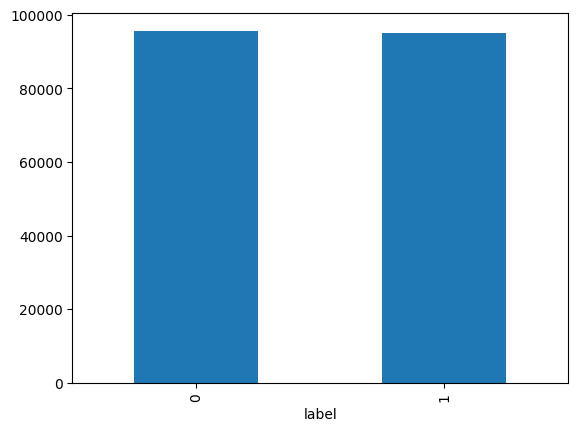

In [13]:
# 막대그래프로 그려보기 둘다 같은결과나옴
df.label.value_counts().plot(kind='bar')
df.groupby('label').size().plot(kind='bar')

In [14]:
# 입력 데이터와 정답데이터 추출  (list)
token_list = list(df.tokens)
label_list = list(df.label)

In [15]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(token_list, label_list, test_size=0.1, stratify=label_list) # 10%를 테스트데이터로 함, 데이터 쪼갤때 긍정/부정 비율을 원본과 똑같이 유지
# 토큰화된 리스트를 넣으면 더효율적임. 근데 벡터화할떄 tokenizer=lambda x: x 로 아무것도 안한다고 덮어 씌워야함
len(train_X), len(test_X), len(train_Y), len(test_Y)

(171662, 19074, 171662, 19074)

### 1-4. 학습 데이터 준비
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV에 할당)

In [16]:
# 단어 수 제한없이 Tokenizer 생성하여 단어 수 확인
from keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer() # oov_token='OOV'

# 특징 집합 생성 및 정수 indexing
tokenizer.fit_on_texts(train_X) # 빈도수 세서 정렬 및 고유 번호 매겨서 등록
len(tokenizer.word_index) # word_index : 단어:번호 형태의 딕셔너리 사전. 중복없는 단어 수
# 입력 텍스트 리스트의 integer encoding
# encoded_texts = tokenizer.texts_to_sequences(df.tokens)
# print(encoded_texts)


46664

In [19]:
from mylib.my_utils import rare_word_status
threshold = 2
rare_word_status(threshold, tokenizer.word_counts.items()) # word_counts : 단어:빈도수 딕셔너리

전체단어 : 46,664개 1,876,353번
희귀단어 : 19,803개 19,803번
희귀단어비율 : 42.44%, 빈도수 비율 : 1.06%
희귀 단어를 뺀 단어 수 : 26,861개 98.94%


In [20]:
# 단어 수를 제한하여 tokenizer 생성
num_vocab = 26861
num_words = num_vocab + 1
tokenizer = Tokenizer(num_words=num_words, oov_token='OOV') # 희귀단어 빼고 토크나이저 생성
tokenizer.fit_on_texts(train_X) # 빈도수 세서 정렬 및 고유 번호 매겨서 등록
len(tokenizer.word_index), tokenizer.num_words # 아직은 단어 전부 기억하고있음. texts_to_sequences() 실행할때 num_words일함

(46665, 26862)

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 review는 단어가 0이 되므로 결측치에 해당 -> 결측치 제거

In [21]:
# 입력 데이터 Integer Encoding
encoded_train_X = tokenizer.texts_to_sequences(train_X) # 17만개 문장을 tokenizer에 등록된 빈도수 26862개 단어 번호로 분류해서 encoding
print(len(encoded_train_X))
print(encoded_train_X[:5])

171662
[[36, 2117, 354, 1664], [129, 304, 172, 802, 155, 2968, 81, 403, 2865, 731, 89, 679, 1240, 129, 2291, 369, 775, 24, 247], [401, 3387, 530, 113, 209, 673, 3, 102, 4612, 207, 867, 10795, 803, 1103, 3293], [5523, 1280, 41, 70, 1280, 41, 132, 74, 191, 358, 364, 223, 1280, 72, 260, 57, 5, 38, 5, 266, 29, 63, 572, 17, 55, 663, 49, 5523, 207, 136, 1901, 787, 1517, 4285, 8], [508, 51, 57, 634, 222, 498, 2]]


In [22]:
# 길이가 0인 리뷰의 index 추출
null_index = set([idx for idx, review in enumerate(encoded_train_X) if not len(review)])
len(null_index)

12

In [ ]:
# 길이가 존재하는 리뷰만 새로 생성
new_train_X = []
new_train_Y = []
for idx, review in enumerate(encoded_train_X):
    if idx not in null_index:
        new_train_X.append(review)
        new_train_Y.append(train_Y[idx])
len(new_train_X), len(new_train_Y)

(171650, 171650)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

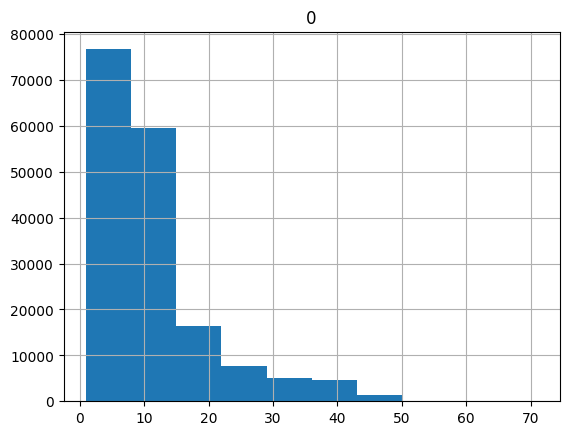

In [24]:
# 리뷰 길이 분포 확인 (히스토그램 그려보기)
len_df = pd.DataFrame([len(review) for review in new_train_X])
len_df.hist()

In [25]:
# 최대, 최소, 평균 등 정보 확인
len_df.describe()

,0
count,171650.000000
mean,10.931273
std,8.874806
min,1.000000
25%,5.000000
50%,8.000000
75%,13.000000
max,71.000000


In [ ]:
# 전체 단어 길이의 99퍼 데이터 찾기
from mylib.my_utils import below_threshold_len_split
max_len = below_threshold_len_split(99, new_train_X)
max_len

42

In [27]:
# max_len 길이로 입력 데이터 padding
from keras.utils import pad_sequences
train_X = pad_sequences(new_train_X, maxlen=max_len)
len(train_X), train_X[:2]

(171650,
 array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,   36, 2117,  354, 1664],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,  129,  304,  172,  802,  155, 2968,   81,  403, 2865,  731,
           89,  679, 1240,  129, 2291,  369,  775,   24,  247]]))

#### 1-4-4. 정답 데이터 one-hot encoding

In [28]:
from keras.utils import to_categorical
train_Y = to_categorical(new_train_Y)
len(train_Y), train_Y[:2]

(171650,
 array([[1., 0.],
        [1., 0.]], dtype=float32))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치제거) 
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [29]:
# 입력 데이터 Integer Encoding
encoded_test_X = tokenizer.texts_to_sequences(test_X)
print(len(encoded_test_X), encoded_test_X[:2])

19074 [[26, 1772, 6827, 4, 111, 151, 114, 2856, 30], [269, 21, 321]]


In [30]:
# 길이가 0인 리뷰의 index 추출 -> 있으면 길이가 1 이상인 리뷰만으로 테스트 데이터 재구성 
null_index = set([index for index, review in enumerate(encoded_test_X) if len(review)])

In [31]:
new_test_X = [review for index, review in enumerate(encoded_test_X) if index in null_index]
new_test_Y = [label for index, label in enumerate(test_Y) if index in null_index]
len(new_test_X), len(new_test_Y)

(19073, 19073)

In [32]:
# 입력 데이터 padding
test_X = pad_sequences(new_test_X, maxlen=max_len)
len(test_X), test_X[:2]

(19073,
 array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           26, 1772, 6827,    4,  111,  151,  114, 2856,   30],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,  269,   21,  321]]))

In [33]:
# 정답 데이터 one-hot encoding
test_Y = to_categorical(new_test_Y)
len(test_Y), test_Y[:2]

(19073,
 array([[0., 1.],
        [0., 1.]], dtype=float32))

## 2. 모델 구축 및 컴파일

In [60]:
from keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
num_features = num_words
embedding_dim = 32
rnn_nodes = 32
dense_nodes = 16
rnn_model = [
    Embedding(num_features, embedding_dim), # 단어들을 거리기반으로 가까운단어인지 학습
    Dropout(0.3), # 임베딩 단어정보중 무작위로 20%를 지워버림. 
    Bidirectional(LSTM(rnn_nodes, dropout=0.2)), # 문장을 양방향으로 읽고 기억전달시 10%씩 정보 누락시켜서 힌트 찾도록 유도
    Dense(dense_nodes, activation='relu'), # 32개로 압축
    Dropout(0.3),
    Dense(2, activation='softmax') # 최종 판단내리기
]

In [61]:
# 모델 설계
from keras.models import Sequential
model = Sequential(rnn_model)
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, None, 32)          859584    
                                                                 
 dropout_10 (Dropout)        (None, None, 32)          0         
                                                                 
 bidirectional_5 (Bidirectio  (None, 64)               16640     
 nal)                                                            
                                                                 
 dense_10 (Dense)            (None, 16)                1040      
                                                                 
 dropout_11 (Dropout)        (None, 16)                0         
                                                                 
 dense_11 (Dense)            (None, 2)                 34        
                                                      

In [62]:
# 모델 생성
from keras.optimizers import RMSprop
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer=RMSprop(learning_rate=0.001)) # 학습률 기본(0.001) 변경할필요없으면 import 안하고 걍 'rmsprop'하면됨

In [63]:
# 모델 컴파일
from keras.callbacks import EarlyStopping, ModelCheckpoint # 장애 복구 시점
es = EarlyStopping(monitor='val_loss',         # 1. 무엇을 감시할 것인가? (보통 검증 손실인 val_loss를 봅니다)
    patience=5,                 # 2. 성능이 안 좋아져도 몇 번(epoch)까지 참아줄 것인가?
    mode='min',                 # 3. 손실(loss)은 작을수록 좋으므로 'min' (정확도면 'max')
    restore_best_weights=True, verbose=1)
mc = ModelCheckpoint(filepath='model/best_model.h5', # 1. 저장할 파일 이름 및 경로
    monitor='val_loss',          # 2. 어떤 점수를 기준으로 저장할지 지정
    save_best_only=True,         # 3. ⭐️ 필수! 전보다 점수가 '더 좋아졌을 때만' 덮어쓰기 (용량 아끼기)
    mode='min')

## 3. 모델 학습

In [64]:
# 모델 학습
model.fit(train_X, train_Y, epochs=40, batch_size=128, validation_split=0.1, callbacks=[es, mc])

Epoch 1/40
1207/1207 [==============================] - 14s 10ms/step - loss: 0.4248 - accuracy: 0.8064 - val_loss: 0.3609 - val_accuracy: 0.8397
Epoch 2/40
1207/1207 [==============================] - 11s 9ms/step - loss: 0.3643 - accuracy: 0.8436 - val_loss: 0.3552 - val_accuracy: 0.8439
Epoch 3/40
1207/1207 [==============================] - 11s 9ms/step - loss: 0.3513 - accuracy: 0.8499 - val_loss: 0.3429 - val_accuracy: 0.8480
Epoch 4/40
1207/1207 [==============================] - 12s 10ms/step - loss: 0.3404 - accuracy: 0.8557 - val_loss: 0.3351 - val_accuracy: 0.8542
Epoch 5/40
1207/1207 [==============================] - 12s 10ms/step - loss: 0.3308 - accuracy: 0.8609 - val_loss: 0.3296 - val_accuracy: 0.8559
Epoch 6/40
1207/1207 [==============================] - 11s 9ms/step - loss: 0.3231 - accuracy: 0.8652 - val_loss: 0.3312 - val_accuracy: 0.8559
Epoch 7/40
1207/1207 [==============================] - 11s 9ms/step - loss: 0.3170 - accuracy: 0.8681 - val_loss: 0.3273 - val

## 4. 모델 평가

In [65]:
# 저장된 모델 로딩하여, 테스트 데이터로 평가
# restore_best_weights = True해서 모델 로딩 안해도됨
test_loss, test_acc = model.evaluate(test_X, test_Y)
print(f'정확도 : {test_acc*100:.2f}% 손실율 : {test_loss*100:.2f}%')

597/597 [==============================] - 3s 4ms/step - loss: 0.3234 - accuracy: 0.8613
정확도 : 86.13% 손실율 : 32.34%


In [ ]:
# predict로 테스트 데이터의 예측값 구기기
results = model.predict(test_X)
print(results[:5])
import numpy as np
labels=['부정', '긍정']
result_index = np.argmax(results, axis=1) # 행기준으로 최댓값 인덱스 모아서 리스트로 반환
result_list = [labels[idx] for idx in result_index]
result_list[:10]

597/597 [==============================] - 2s 3ms/step
[[0.7198399  0.28016007]
 [0.16477582 0.8352242 ]
 [0.15350774 0.8464923 ]
 [0.11823729 0.8817627 ]
 [0.9848454  0.01515455]]


['부정', '긍정', '긍정', '긍정', '부정', '긍정', '긍정', '부정', '긍정', '부정']

In [67]:
# sklearn의 classification_report()로 평가 결과 확인
from sklearn.metrics import classification_report
print(classification_report(new_test_Y, result_index)) # 원핫 인코딩하기전, (0,1) 만 있는상태 가져오기

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      9566
           1       0.86      0.86      0.86      9507

    accuracy                           0.86     19073
   macro avg       0.86      0.86      0.86     19073
weighted avg       0.86      0.86      0.86     19073



## 5. 예측

In [68]:
# 입력된 리뷰에 대한 긍부정 판단 함수
def sentiment_predict(text):
    tokens = tokenize_and_remove_stopwords(text)
    encoded_tokens = tokenizer.texts_to_sequences([tokens]) # texts_to_sequences 는 2차원 리스트 넣어야됨
    X = pad_sequences(encoded_tokens, maxlen=max_len)
    result = model.predict(X)
    labels=['부정', '긍정']
    result_index = np.argmax(result[0])
    output = labels[result_index]
    return output, result[0][result_index]
# 데이터 준비 : 정제, 한국어 형태소 분석, integer encoding, padding


In [69]:
# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]
for review in reviews:
    output, prob = sentiment_predict(review)
    print(f'{review} --> {output}({prob*100:.2f}%)')


1/1 [==============================] - 0s 19ms/step
이 영화 개꿀잼 ㅋㅋㅋ --> 긍정(89.14%)
1/1 [==============================] - 0s 15ms/step
하품만 나온다 --> 부정(98.20%)
1/1 [==============================] - 0s 15ms/step
이 영화 핵노잼 ㅠㅠ --> 부정(99.34%)
1/1 [==============================] - 0s 20ms/step
이딴게 영화냐 ㅉㅉ --> 부정(99.91%)
1/1 [==============================] - 0s 15ms/step
와 개쩐다 --> 긍정(88.03%)
1/1 [==============================] - 0s 15ms/step
감독 뭐하는 놈이냐 --> 부정(98.04%)
1/1 [==============================] - 0s 26ms/step
정말 세계관 최강자들의 영화다 --> 긍정(52.45%)


## 6. 배포 (모델 저장 및 재사용)
    6-1. 모델 저장
    6-2. SentimentAnalyzer 클래스 구현
        *  저장된 모델 로딩 및 사용

### 6-1. 모델 저장 

In [ ]:
# okt, tokenizer, 학습한 model 저장
# keras 학습 모델저장
model.save('model/sa_movie_model.keras')

In [71]:
# Integer Encoding을 위한 파이썬 객체 직렬화 (encoder) : tokenizer
import joblib
joblib.dump(tokenizer, 'model/sa_movie_encoder.pkl')

['model/sa_movie_encoder.pkl']

### 6-2. SentimentAnalyzer 클래스 구현
- 객체 생성 시 예측 모델, Integer Encoder 로딩
- 한국어 형태소 분석기 정의
- 입력된 리뷰의 긍부정 판단 함수

In [ ]:
from keras.models import load_model
from konlpy.tag import Okt
import joblib
from keras.utils import pad_sequences
class DeepSentimentAnalyzer:
    def __init__(self, model_file, encoder_file):
        self.model =  load_model(model_file)
        self.encoder = joblib.load(encoder_file)
        self.maxlen = 42
    def tokenize_and_remove_stopwords(self,text):
    # 혹시 모를 결측치(NaN/None) 에러 방지용 안전장치
        if not isinstance(text, str):
            return []
        
        # 1단계: 형태소 분석 및 어간 추출 (예: '재밌네요' -> '재밌다')
        tokens = Okt().morphs(text, stem=True)
        
        # 2단계: 뽑아낸 토큰 중 불용어 리스트에 없는 단어만 남기기
        clean_tokens = [word for word in tokens if word not in stopwords]
        
        return clean_tokens
    
    def sentiment_predict(self, text):
        tokens = [word for word in self.tokenize_and_remove_stopwords(text)]
        encoded_tokens = self.encoder.texts_to_sequence([tokens])
        X = pad_sequences(encoded_tokens, maxlen=self.maxlen) # model에 input length 추가
        result = self.model.predict(X, verbose=0)
        labels=['부정', '긍정']
        result_index = np.argmax(result[0])
        output = labels[result_index]
        return output, result[0][result_index]

In [76]:
sa = DeepSentimentAnalyzer('model/sa_movie_model.keras', 'model/sa_movie_encoder.pkl')
# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]
for review in reviews:
    output, prob = sentiment_predict(review)
    print(f'{review} --> {output}({prob*100:.2f}%)')

1/1 [==============================] - 0s 20ms/step
이 영화 개꿀잼 ㅋㅋㅋ --> 긍정(89.14%)
1/1 [==============================] - 0s 30ms/step
하품만 나온다 --> 부정(98.20%)
1/1 [==============================] - 0s 16ms/step
이 영화 핵노잼 ㅠㅠ --> 부정(99.34%)
1/1 [==============================] - 0s 12ms/step
이딴게 영화냐 ㅉㅉ --> 부정(99.91%)
1/1 [==============================] - 0s 5ms/step
와 개쩐다 --> 긍정(88.03%)
1/1 [==============================] - 0s 12ms/step
감독 뭐하는 놈이냐 --> 부정(98.04%)
1/1 [==============================] - 0s 15ms/step
정말 세계관 최강자들의 영화다 --> 긍정(52.45%)
